In [1]:
!pip install control numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import control as ct

print("Libraries imported successfully.")

Defaulting to user installation because normal site-packages is not writeable
Libraries imported successfully.


In [2]:
# --- Configuration Toggle ---
use_state_space = False # Set to True to use State-Space; False for Transfer Function

# --- Provided Input Variables ---
num = [1]
den = [1, 1, 1]

# State-Space parameters
A = [[0, 1], [-1, -1]]
B = [[0], [1]]
C = [[0, 1]]
D = [[0]]

def define_lti_system():
    try:
        if use_state_space:
            mat_a, mat_b = np.array(A), np.array(B)
            mat_c, mat_d = np.array(C), np.array(D)
            sys = ct.ss(mat_a, mat_b, mat_c, mat_d)
            print("System successfully defined using State-Space representation.")
        else:
            sys = ct.tf(num, den)
            print("System successfully defined using Transfer Function representation.")
        return sys
    except Exception as e:
        print(f"Error defining system: {e}")
        return None

sys = define_lti_system()
if sys is not None:
    print("\nSystem Model:")
    print(sys)# --- Configuration Toggle ---
use_state_space = False # Set to True to use State-Space; False for Transfer Function

# --- Provided Input Variables ---
num = [1]
den = [1, 1, 1]

# State-Space parameters
A = [[0, 1], [-1, -1]]
B = [[0], [1]]
C = [[0, 1]]
D = [[0]]

def define_lti_system():
    try:
        if use_state_space:
            mat_a, mat_b = np.array(A), np.array(B)
            mat_c, mat_d = np.array(C), np.array(D)
            sys = ct.ss(mat_a, mat_b, mat_c, mat_d)
            print("System successfully defined using State-Space representation.")
        else:
            sys = ct.tf(num, den)
            print("System successfully defined using Transfer Function representation.")
        return sys
    except Exception as e:
        print(f"Error defining system: {e}")
        return None

sys = define_lti_system()
if sys is not None:
    print("\nSystem Model:")
    print(sys)

System successfully defined using Transfer Function representation.

System Model:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       1
  -----------
  s^2 + s + 1
System successfully defined using Transfer Function representation.

System Model:
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       1
  -----------
  s^2 + s + 1


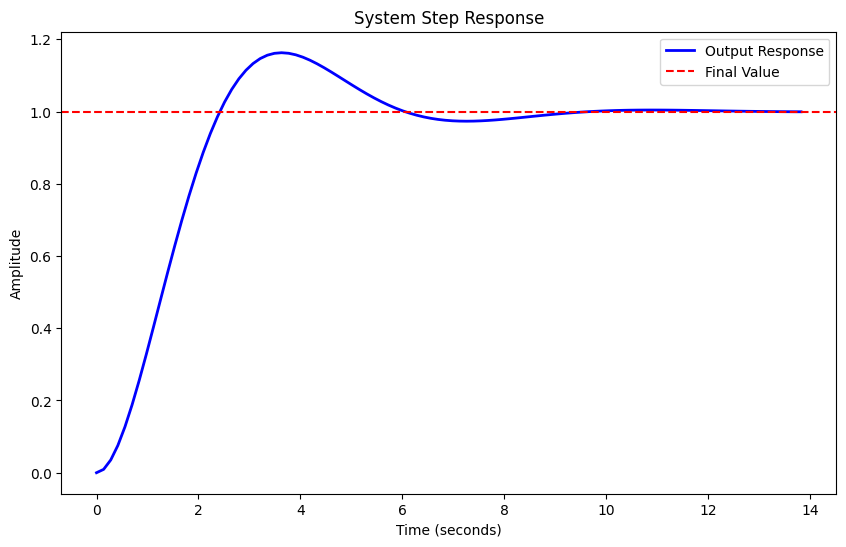

------------------------------
STEP RESPONSE METRICS
------------------------------
Rise Time:      1.6746 s
Settling Time:  8.0939 s
Peak Overshoot: 16.30 %
Peak Value:     1.1630


In [3]:
if sys is not None:
    # 1. Calculate Step Response
    t, y = ct.step_response(sys)
    
    # 2. Extract Performance Metrics
    info = ct.step_info(sys)
    
    # 3. Plotting the response
    plt.figure(figsize=(10, 6))
    plt.plot(t, y, label='Output Response', color='blue', linewidth=2)
    plt.axhline(1.0, color='red', linestyle='--', label='Final Value')
    plt.title('System Step Response')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()
    
    # 4. Display Metrics
    print("-" * 30)
    print("STEP RESPONSE METRICS")
    print("-" * 30)
    print(f"Rise Time:      {info['RiseTime']:.4f} s")
    print(f"Settling Time:  {info['SettlingTime']:.4f} s")
    print(f"Peak Overshoot: {info['Overshoot']:.2f} %")
    print(f"Peak Value:     {info['Peak']:.4f}")

C:\Users\Nex\AppData\Roaming\Python\Python313\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


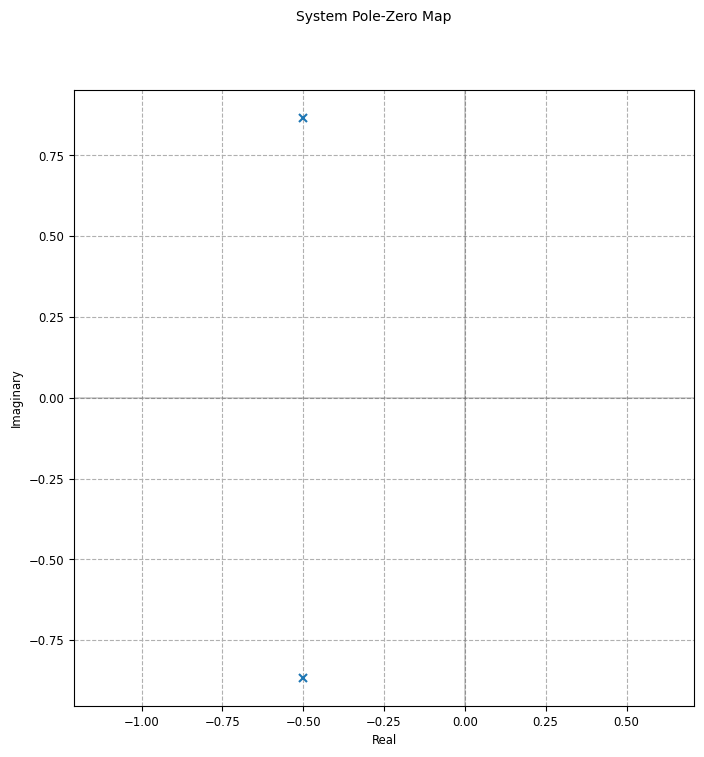

------------------------------
STABILITY ANALYSIS
------------------------------
System Poles: [-0.5+0.8660254j -0.5-0.8660254j]
Verdict: The system is ASYMPTOTICALLY STABLE.


In [4]:
if sys is not None:
    # 1. Generate Pole-Zero Map
    plt.figure(figsize=(8, 8))
    ct.pzmap(sys, plot=True, title='System Pole-Zero Map')
    plt.grid(True, linestyle='--')
    plt.show()
    
    # 2. Stability Analysis
    poles = ct.poles(sys)
    real_parts = np.real(poles)
    
    print("-" * 30)
    print("STABILITY ANALYSIS")
    print("-" * 30)
    print(f"System Poles: {poles}")
    
    if np.all(real_parts < 0):
        print("Verdict: The system is ASYMPTOTICALLY STABLE.")
    elif np.any(real_parts > 0):
        print("Verdict: The system is UNSTABLE.")
    else:
        print("Verdict: The system is MARGINALLY STABLE.")